## TELECOMMUNICATION CUSTOMER CHURN ANALYSIS

The objective of this project is to analyze telecom customer behavior and identify the customer traits most correlated with churn rates in order to support retention strategy.  

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [76]:
telecom = pd.read_csv('Telecom Customers Churn.csv')
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## DATASET OVERVIEW
In this section, the telecom customer dataset is loaded and its structure, columns, and data quality are briefly outlined. This is helpful in determining the variables that are available for churn analysis as well as any problems that would need to be fixed before any analysis.

In [92]:
telecom.shape

(7032, 21)

In [93]:
telecom.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

telecom.isnull().sum()

## INITIAL OBSERVATIONS
The telecom dataset includes data on customer demographics, services, billing, and churn. Tenure, monthly costs, total charges, and contract type are important factors that affect churn analysis. The dataset appears to be suitable for determining churn drivers and retention trends based on preliminary analysis.

## DATA CLEANING
This section validates that crucial variables are in the appropriate data type for analysis and standardizes column formatting. Accurate churn analysis requires clean, consistent data.

In [78]:
telecom.columns = telecom.columns.str.strip().str.lower().str.replace(" ", "_")
telecom.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

## OVERALL CHURN RATE

This measures the customer percentage who churned from telecom rather than remaining active. This provides a retention baseline for the telecom business. 

In [95]:
telecom["churn"].value_counts()
telecom["churn"].value_counts(normalize = True) * 100

churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

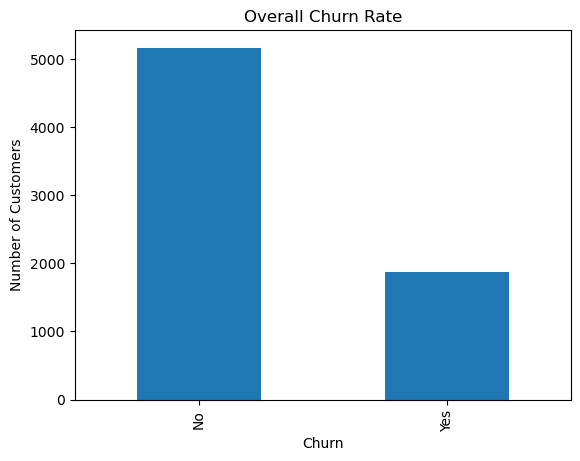

In [96]:
telecom["churn"].value_counts().plot(kind = "bar", title = "Overall Churn Rate")
plt.ylabel("Number of Customers")
plt.xlabel("Churn")
plt.show()

### Insight

The overall churn rate indicates that a sizeable percentage of telecom users discontinued their services. This creates a baseline for identifying high-risk customer segments and emphasizes customer retention as a critical business proiority.  

## TENURE BY CHURN

This measures the average length of time customers remained with the telecom company based upon churn status. It identifies whether customers who leave tend to have shorter relationships with the business than those who remain. 

In [80]:
telecom.groupby("churn")["tenure"].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

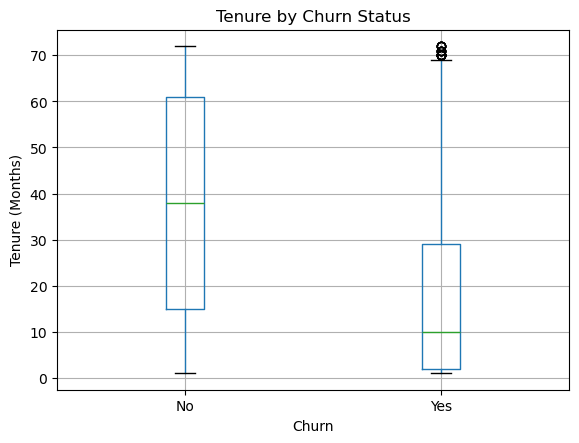

In [97]:
telecom.boxplot(column = "tenure", by = "churn")
plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Insight

Generally, customers who churned had shorter tenure than actives ones. This implies that turnover is more likely to happen early in the customer lifetime, suggesting that efforts to retan customers should concentrate on those who are more recent. 

## MONTHLY CHARGES BY CHURN

This measures the monthly amount customers are charged for services based on churn status   It assesses whether higher recurring costs may be associated with an increased probability of customer churn. 

In [81]:
telecom.groupby("churn")["monthlycharges"].mean()

churn
No     61.265124
Yes    74.441332
Name: monthlycharges, dtype: float64

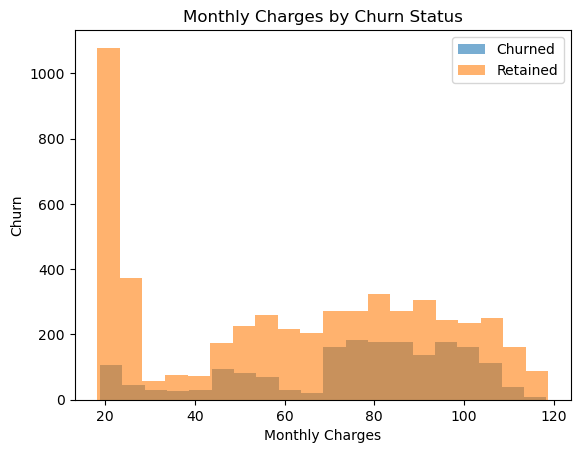

In [98]:
telecom[telecom["churn"] == "Yes"]["monthlycharges"].plot(kind = "hist", bins = 20, alpha = 0.6, label = "Churned")
telecom[telecom["churn"] == "No"]["monthlycharges"].plot(kind = "hist", bins = 20, alpha = 0.6, label = "Retained")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.legend()
plt.show()

### Insight

On average, monthly charges were greater for those who churned than those who did not. Thus could suggest that judgements about customer retention are influenced by pricing or perceived service value. 

## TOTAL CHARGES BY CHURN

This measures the total amount that customers have paid over time based on churn status. It evaluates whether customers who leave tend to have lower overall long-term value than those who do not leave the telecom company. 

In [82]:
telecom["totalcharges"] = pd.to_numeric(telecom["totalcharges"], errors = "coerce")
telecom.groupby("churn")["totalcharges"].mean()

churn
No     2555.344141
Yes    1531.796094
Name: totalcharges, dtype: float64

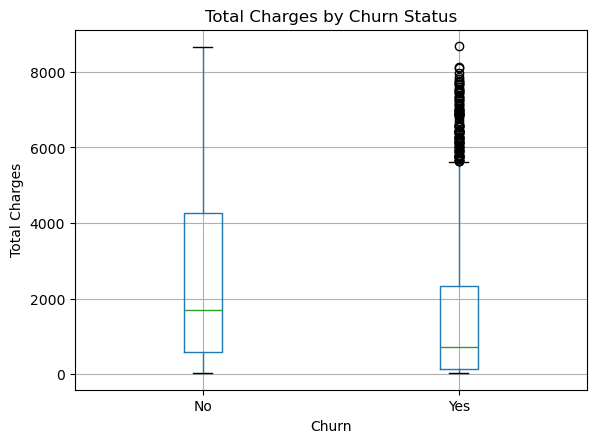

In [99]:
telecom["totalcharges"] = pd.to_numeric(telecom["totalcharges"], errors = "coerce")
telecom = telecom.dropna()
telecom.boxplot(column = "totalcharges", by = "churn")
plt.title("Total Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

### Insight

The overall charged of churned customers were often lower than those who remained. This reflects that churned customers produce lower overall long-term value and generally reflects shorter tenure. 

## CONTRACT TYPE BY CHURN

This measures the relationship between customer contract type and churn status. It determines whether customers on shorter-term or lower-commitment plans are more likely to seperate from their telecom services. 

In [83]:
pd.crosstab(telecom["contract"], telecom["churn"], normalize = "index") * 100

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


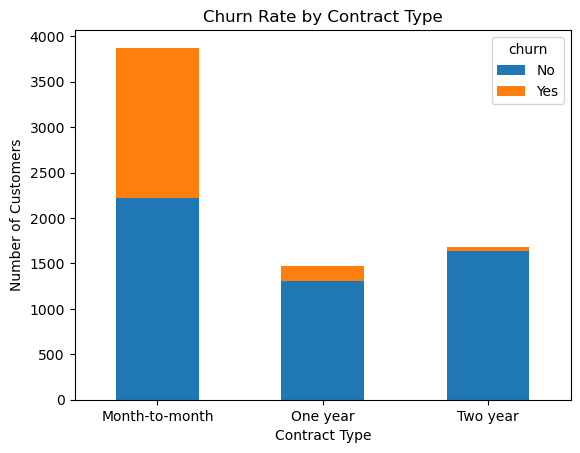

In [100]:
pd.crosstab(telecom["contract"], telecom["churn"]).plot(kind = "bar", stacked = True, title = "Churn Rate by Contract Type", rot = 0)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### Insight

Compared to customers on longer-term contracts, those on month-to-month contracts showed noticeably higher churn rates. This implies that weaker customer retention is correlated with lower-commitment plans. 

## KEY INSIGHTS SUMMARY
- The total churn rate demonstrates that retaining customers is a significant business concern.
- Early in the customer lifecycle, customers with shorter tenure are significantly more likely to churn, indicating increased risk.
- Increased churn appears to be proportional to higher monthly charges, indicating possible issues with pricing or value.
- Churning customers typically have lower overall charges, which reflects a lower lifetime value.
- Month-to-month clients tend to have the greatest churn rates, and contract type is closely associated with churn.

## RECOMMENDATIONS
- Concentrate retention tactics on customers who only recently started out.
- For higher monthly charge groups, assess pricing or value perception.
- Promote customers to switch from month-to-month agreements to longer-term ones.
- For retention campaigns, identify and target high-risk customers using tenure, pricing, and contract type.

## CONCLUSION
In conclusion, this analysis found that a number of customer traits, such as shorter tenure, higher monthly costs, lower total costs, and month-to-month contract arrangements, are linked to churn. According to these results, retention tactics that emphasize contract commitment and early customer lifecycle stages may lower attrition and increase customer lifetime value.